<a href="https://colab.research.google.com/github/Shrawanpandit/ImageProcessing-Lab-works/blob/main/Image_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# image Segmentation

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.measure import label

read image

In [17]:
im=cv2.imread("number_plate.jpg")

convert BGR TO RGB(for displaying)

In [18]:
im_rgb=cv2.cvtColor(im,cv2.COLOR_BGR2RGB)


convert to grayscale

In [19]:
im_gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)


Median filtering

In [20]:
im_median_blurred = cv2.medianBlur(im_gray, 3)


sobel edge detection

In [21]:
grad_x=cv2.Sobel(im_median_blurred, cv2.CV_64F, 1, 0, ksize=3)
grad_y=cv2.Sobel(im_median_blurred, cv2.CV_64F, 0, 1, ksize=3)
magnitude=np.sqrt(grad_x**2 + grad_y**2)
Bw=(magnitude > 100).astype(np.uint8)



image dimension

In [22]:
imx,imy=Bw.shape

mask

In [23]:
msk = np.array([
[0, 0, 0, 0, 0],
[0, 1, 1, 1, 0],
[0, 1, 1, 1, 0],
[0, 1, 1, 1, 0],
[0, 0, 0, 0, 0]
], dtype=np.uint8)

convolution

In [24]:
B = convolve2d(Bw.astype(float), msk.astype(float), mode='same')

connected component labeling


In [25]:
L = label(B > 0, connectivity=2)

mx = L.max()
print("Total Connected Components:", mx)

Total Connected Components: 96


MATLAB extracts component 17

In [26]:
component_number = 17

n1 = np.zeros((imx, imy), dtype=np.uint8)

if component_number <= mx:
    r, c = np.where(L == component_number)
    n1[r, c] = 255
else:
    print(f"Component {component_number} not found.")

Display results

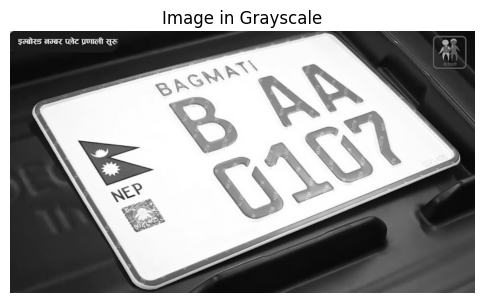

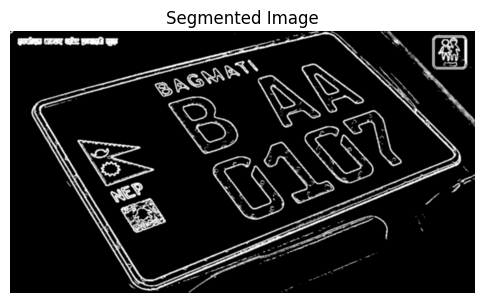

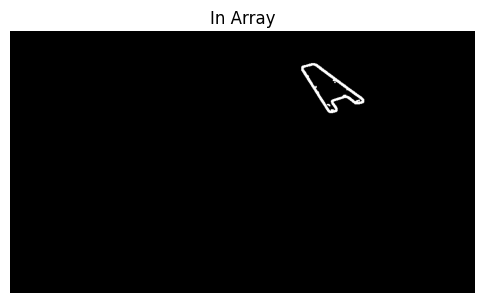

In [27]:
plt.figure(figsize=(6,6))
plt.imshow(im_gray, cmap='gray')
plt.title("Image in Grayscale")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(B, cmap='gray')
plt.title("Segmented Image")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(n1, cmap='gray')
plt.title("In Array")
plt.axis("off")

plt.show()

pattern Recognition

In [28]:
import cv2
import matplotlib.pyplot as plt

# Load Haar Cascade face detector
face_detector = cv2.CascadeClassifier(
cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

open the video file

In [44]:
video = cv2.VideoCapture("video.mp4")

read the first frame

In [43]:
import cv2

video = cv2.VideoCapture("video.mp4")

ret, frame = video.read()

if not ret:
    print("Error: Could not read the video.")
else:
    print("Video loaded successfully!")
    print(frame.shape)

Video loaded successfully!
(360, 640, 3)


convert frame to grayscale

In [31]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

Detect faces

In [32]:
import cv2

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_detector.detectMultiScale(
gray,
scaleFactor=1.1,
minNeighbors=5,
minSize=(30, 30)
)

draw rectangles around detected faces

In [33]:
for (x, y, w, h) in faces:
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(frame, "Face", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                (0, 255, 0), 2)

convert BGR TO RGB for matplotlib

In [34]:
frame_rgb=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

Display the reslut

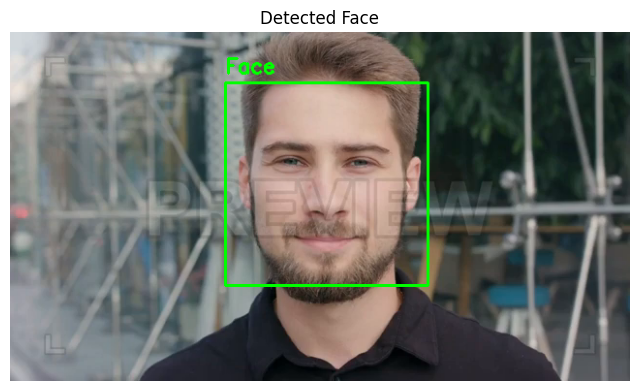

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.title("Detected Face")
plt.axis("off")
plt.show()

Release the video